In [1]:
import os
os.environ["PYSPARK_PYTHON"] = 'python'
os.makedirs("Figures", exist_ok=True)
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
spark = (
    SparkSession.builder.appName("SCOX_Full_EDA")
    .config("spark.sql.session.timeZone", "UTC")
    .master("local[*]").getOrCreate()
)

In [3]:
print("Session timezone:", spark.conf.get("spark.sql.session.timeZone"))

Session timezone: UTC


In [4]:
timetable = spark.read.csv("Data\FinalCSV\clean_timetabledata.csv", header=True, inferSchema=True)
fares = spark.read.csv("Data\FinalCSV\clean_fares.csv", header=True, inferSchema=True)
location = spark.read.csv("Data\FinalCSV\compiled_location_data.csv", header=True, inferSchema=True)
disruption = spark.read.csv("Data\FinalCSV\clean_disruptiondata.csv", header=True, inferSchema=True)

In [5]:
# Timetable EDA
print("=== Timetable: shape ===")
print(timetable.count(), "rows,", len(timetable.columns), "cols")
timetable.printSchema()

print("=== Timetable: null counts ===")
timetable.select([
    count(when(col(c).isNull(), c)).alias(c) for c in timetable.columns
]).show()

print("=== Timetable: cardinality ===")
timetable.select([
    countDistinct(col(c)).alias(c) for c in timetable.columns
]).show()

timetable = timetable.withColumn(
    "run_time_minutes",
    regexp_extract(col("RunTime"), r'PT(\d+)M', 1).cast("int")
    + regexp_extract(col("RunTime"), r'M(\d+)S', 1).cast("int") / 60.0
)

print("=== Timetable: RunTime (minutes) descriptive stats ===")
timetable.select("run_time_minutes").describe().show()
median_runtime = timetable.approxQuantile("run_time_minutes", [0.5], 0.01)[0]
print(f"Median run_time_minutes: {median_runtime:.2f}")

timetable.select(
    skewness("run_time_minutes").alias("run_time_skewness"),
    kurtosis("run_time_minutes").alias("run_time_kurtosis")
).show()

quantiles_tt = timetable.approxQuantile("run_time_minutes", [0.25, 0.75], 0.01)
q1_tt, q3_tt = quantiles_tt[0], quantiles_tt[1]
iqr_tt = q3_tt - q1_tt
lower_tt = q1_tt - 1.5 * iqr_tt
upper_tt = q3_tt + 1.5 * iqr_tt
print(f"IQR bounds for run_time_minutes: [{lower_tt:.2f}, {upper_tt:.2f}]")

outliers_tt = timetable.filter((col("run_time_minutes") < lower_tt) | (col("run_time_minutes") > upper_tt))
print(f"Outlier legs: {outliers_tt.count()} of {timetable.count()}")

print("=== Outlier legs by line (top 10) ===")
outliers_tt.groupBy("LineName").count().orderBy(desc("count")).show(10)

print("=== Timetable: trips + legs per line (full) ===")
line_summary_tt = timetable.groupBy("LineName").agg(
    count("*").alias("n_legs"),
    countDistinct("JourneyCode").alias("n_trips"),
    round(avg("run_time_minutes"), 2).alias("avg_leg_minutes")
).orderBy(desc("n_legs"))
line_summary_tt.show(42)

print("=== Timetable: busiest stops (by leg count) ===")
timetable.groupBy("StopName").count().orderBy(desc("count")).show(10)

=== Timetable: shape ===
176615 rows, 7 cols
root
 |-- ServiceCode: string (nullable = true)
 |-- LineName: string (nullable = true)
 |-- JourneyCode: string (nullable = true)
 |-- StopPointRef: string (nullable = true)
 |-- StopName: string (nullable = true)
 |-- RunTime: string (nullable = true)
 |-- Source: string (nullable = true)

=== Timetable: null counts ===
+-----------+--------+-----------+------------+--------+-------+------+
|ServiceCode|LineName|JourneyCode|StopPointRef|StopName|RunTime|Source|
+-----------+--------+-----------+------------+--------+-------+------+
|          0|       0|          0|           0|       0|      0|     0|
+-----------+--------+-----------+------------+--------+-------+------+

=== Timetable: cardinality ===
+-----------+--------+-----------+------------+--------+-------+------+
|ServiceCode|LineName|JourneyCode|StopPointRef|StopName|RunTime|Source|
+-----------+--------+-----------+------------+--------+-------+------+
|         28|      42| 

In [6]:
#location EDA
print("=== Location: shape ===")
print(location.count(), "rows,", len(location.columns), "cols")

key_cols = ["LineRef", "RecordedAtTime", "OperatorRef", "Longitude", "Latitude", "OriginAimedDepartureTime"]
print("=== Location: null counts (key columns only, full table is wide) ===")
location.select([
    count(when(col(c).isNull(), c)).alias(c) for c in key_cols
]).show()

print("=== Location: cardinality on key columns ===")
location.select([countDistinct(col(c)).alias(c) for c in key_cols]).show()
OXFORDSHIRE_LAT_RANGE = (51.5, 52.1)
OXFORDSHIRE_LON_RANGE = (-1.7, -0.9)

geo_outliers = location.filter(
    (col("Latitude") < OXFORDSHIRE_LAT_RANGE[0]) | (col("Latitude") > OXFORDSHIRE_LAT_RANGE[1]) |
    (col("Longitude") < OXFORDSHIRE_LON_RANGE[0]) | (col("Longitude") > OXFORDSHIRE_LON_RANGE[1])
)
n_geo_outliers = geo_outliers.count()
print(f"=== Location: GPS points outside Oxfordshire bounding box: {n_geo_outliers} of {location.count()} ===")
if n_geo_outliers > 0:
    geo_outliers.select("LineRef", "Latitude", "Longitude", "OriginName").show(10)

location = location.withColumn("recorded_hour", hour(col("RecordedAtTime")))

print("=== Location: observations by hour of day (UTC-corrected) ===")
location.groupBy("recorded_hour").count().orderBy("recorded_hour").show(24)

print("=== Location: observations per line ===")
location.groupBy("LineRef").count().orderBy(desc("count")).show(15)

=== Location: shape ===
742 rows, 27 cols
=== Location: null counts (key columns only, full table is wide) ===
+-------+--------------+-----------+---------+--------+------------------------+
|LineRef|RecordedAtTime|OperatorRef|Longitude|Latitude|OriginAimedDepartureTime|
+-------+--------------+-----------+---------+--------+------------------------+
|      0|             0|          0|        0|       0|                       0|
+-------+--------------+-----------+---------+--------+------------------------+

=== Location: cardinality on key columns ===
+-------+--------------+-----------+---------+--------+------------------------+
|LineRef|RecordedAtTime|OperatorRef|Longitude|Latitude|OriginAimedDepartureTime|
+-------+--------------+-----------+---------+--------+------------------------+
|     39|           591|          1|      716|     693|                     516|
+-------+--------------+-----------+---------+--------+------------------------+

=== Location: GPS points outside

In [7]:
# Disruption EDA
print("=== Disruption: shape ===")
print(disruption.count(), "rows,", len(disruption.columns), "cols")

print("=== Disruption: null counts ===")
disruption.select([
    count(when(col(c).isNull(), c)).alias(c) for c in disruption.columns
]).show()

disruption.select("DurationHours").describe().show()

# MEDIAN — same gap fix as timetable
median_duration = disruption.approxQuantile("DurationHours", [0.5], 0.01)[0]
print(f"Median DurationHours: {median_duration:.2f}")

disruption.select(
    skewness("DurationHours").alias("duration_skewness"),
    kurtosis("DurationHours").alias("duration_kurtosis")
).show()
quantiles_d = disruption.approxQuantile("DurationHours", [0.25, 0.75], 0.01)
q1_d, q3_d = quantiles_d[0], quantiles_d[1]
iqr_d = q3_d - q1_d
lower_d = q1_d - 1.5 * iqr_d
upper_d = q3_d + 1.5 * iqr_d
print(f"IQR bounds for DurationHours: [{lower_d:.2f}, {upper_d:.2f}]")

outliers_d = disruption.filter((col("DurationHours") < lower_d) | (col("DurationHours") > upper_d))
print(f"Outlier disruptions: {outliers_d.count()} of {disruption.count()}")
outliers_d.select("LineRef", "Severity", "DurationHours").show(20)

disruption.groupBy("Severity").count().orderBy(desc("count")).show()
disruption.groupBy("ReasonCategory").agg(
    count("*").alias("n"), round(avg("DurationHours"), 2).alias("avg_duration")
).orderBy(desc("n")).show()

=== Disruption: shape ===
192 rows, 12 cols
=== Disruption: null counts ===
+---------------+-------+---------------+----------------+--------+--------------+----------+-------+---------+-------+-------------+-----------+
|SituationNumber|LineRef|AffectedStopRef|AffectedStopName|Severity|ReasonCategory|ReasonType|Planned|StartTime|EndTime|DurationHours|IsSynthetic|
+---------------+-------+---------------+----------------+--------+--------------+----------+-------+---------+-------+-------------+-----------+
|              0|      0|              0|               0|       0|             0|         0|      0|        0|      0|            0|          0|
+---------------+-------+---------------+----------------+--------+--------------+----------+-------+---------+-------+-------------+-----------+

+-------+------------------+
|summary|     DurationHours|
+-------+------------------+
|  count|               192|
|   mean| 32.32369791666668|
| stddev|58.105752077343546|
|    min|          

In [8]:
# trip volume frequency
print("=== Trips per line vs disruptions per line ===")
disruption_per_line = disruption.groupBy("LineRef").count().withColumnRenamed("count", "n_disruptions")
cross_check = line_summary_tt.join(
    disruption_per_line, line_summary_tt.LineName == disruption_per_line.LineRef, "left"
).select("LineName", "n_trips", "n_disruptions").fillna(0, subset=["n_disruptions"])
cross_check.orderBy(desc("n_trips")).show(42)
corr_trips_disruptions = cross_check.stat.corr("n_trips", "n_disruptions")
print(f"Pearson correlation (n_trips vs n_disruptions): {corr_trips_disruptions:.4f}")

=== Trips per line vs disruptions per line ===
+--------+-------+-------------+
|LineName|n_trips|n_disruptions|
+--------+-------+-------------+
|       1|    676|            2|
|    TUBE|    559|            1|
|       8|    426|            7|
|       2|    423|            3|
|      2A|    355|            4|
|      S1|    309|            7|
|      S5|    307|            5|
|      B9|    272|            7|
|      E1|    223|            4|
|      12|    212|            8|
|      S9|    207|            0|
|      13|    197|            9|
|      S3|    193|            3|
|      14|    177|            4|
|      S7|    162|            7|
|      B5|    148|            5|
|     800|    134|            9|
|      B3|    124|            5|
|      B4|    122|            5|
|     900|    120|            3|
|      10|    110|            3|
|       9|    103|            4|
|     500|     88|            8|
|      S4|     80|            5|
|      29|     67|            2|
|     233|     65|           

In [13]:
#creating folder to sore visualizations
os.makedirs("Figures", exist_ok=True)

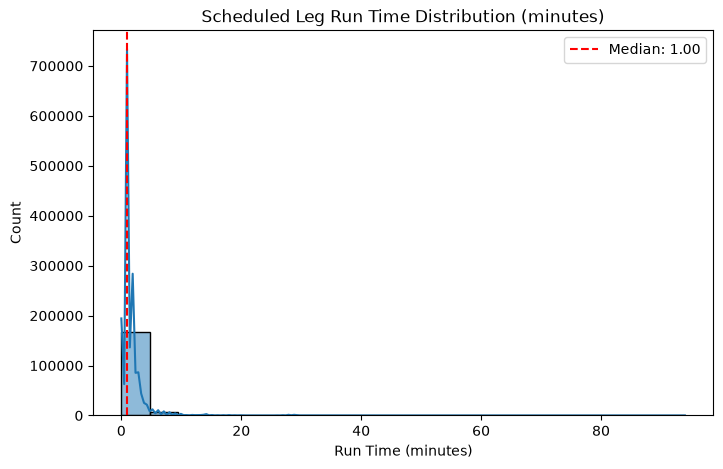

In [14]:
#Run Time Distribution
runtime_pd = timetable.select("run_time_minutes").toPandas()
plt.figure(figsize=(8,5))
sns.histplot(runtime_pd["run_time_minutes"], bins=20, kde=True)
plt.axvline(median_runtime, color='red', linestyle='--', label=f'Median: {median_runtime:.2f}')
plt.title("Scheduled Leg Run Time Distribution (minutes)")
plt.xlabel("Run Time (minutes)")
plt.legend()
plt.savefig("Figures/eda_runtime_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

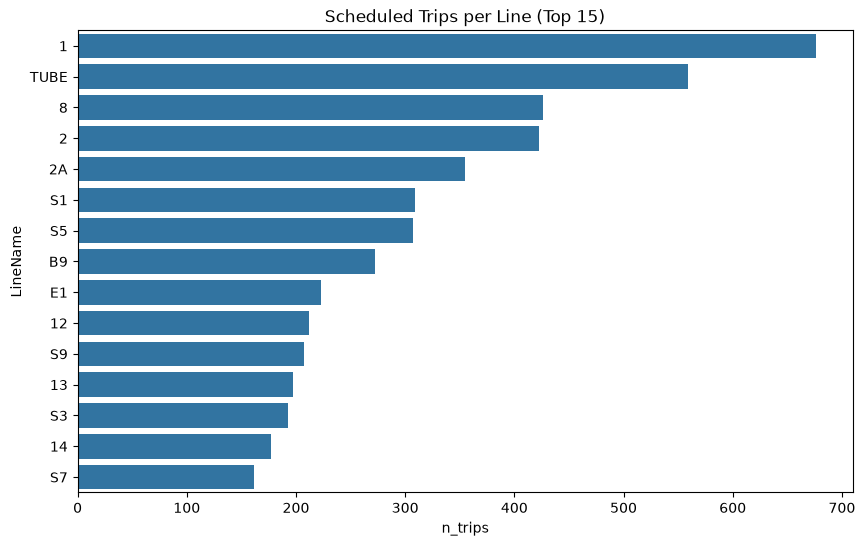

In [15]:
#Top 15 Scheduled Trips per Line
trips_pd = line_summary_tt.orderBy(desc("n_trips")).limit(15).toPandas()
plt.figure(figsize=(10,6))
sns.barplot(data=trips_pd, x="n_trips", y="LineName", orient="h")
plt.title("Scheduled Trips per Line (Top 15)")
plt.savefig("Figures/eda_trips_per_line.png", dpi=150, bbox_inches="tight")
plt.show()

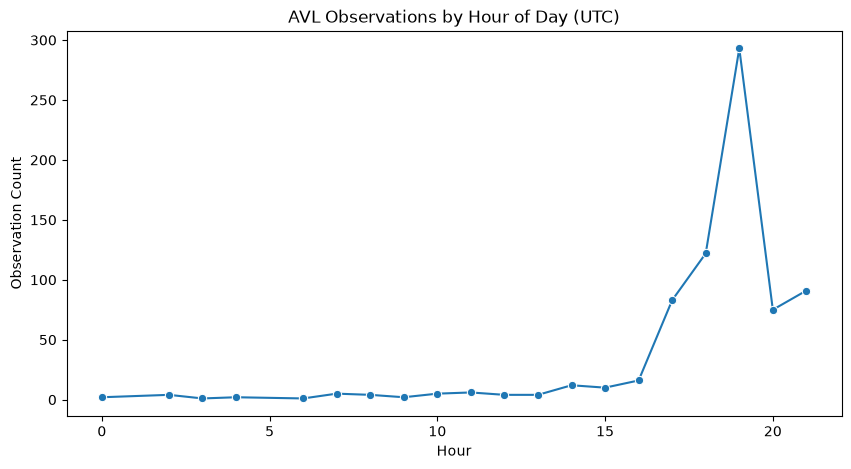

In [16]:
#AVL Observations by Hour
hourly_pd = location.groupBy("recorded_hour").count().orderBy("recorded_hour").toPandas()
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_pd, x="recorded_hour", y="count", marker="o")
plt.title("AVL Observations by Hour of Day (UTC)")
plt.xlabel("Hour")
plt.ylabel("Observation Count")
plt.savefig("Figures/eda_hourly_observations.png", dpi=150, bbox_inches="tight")
plt.show()

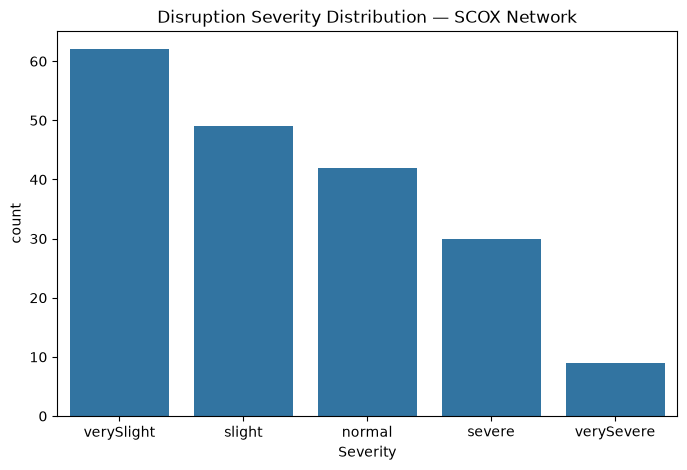

In [17]:
#Disruption Severity Distribution
severity_pd = disruption.groupBy("Severity").count().toPandas()
plt.figure(figsize=(8,5))
sns.barplot(data=severity_pd, x="Severity", y="count",
            order=["verySlight","slight","normal","severe","verySevere"])
plt.title("Disruption Severity Distribution — SCOX Network")
plt.savefig("Figures/eda_severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

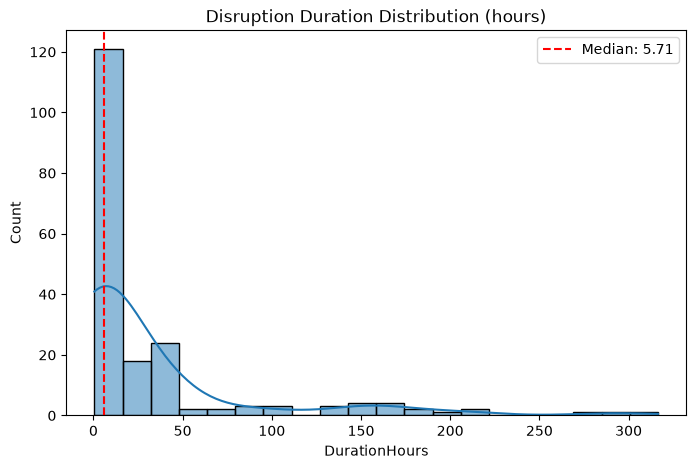

In [18]:
#Disruption Duration Distribution
duration_pd = disruption.select("DurationHours").toPandas()
plt.figure(figsize=(8,5))
sns.histplot(duration_pd["DurationHours"], bins=20, kde=True)
plt.axvline(median_duration, color='red', linestyle='--', label=f'Median: {median_duration:.2f}')
plt.title("Disruption Duration Distribution (hours)")
plt.legend()
plt.savefig("Figures/eda_duration_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
Trip Volume vs Disruption Count Scatter Plot
cross_pd = cross_check.toPandas()
plt.figure(figsize=(8,6))
sns.scatterplot(data=cross_pd, x="n_trips", y="n_disruptions")
plt.title(f"Scheduled Trip Volume vs Disruption Count, per Line (r={corr_trips_disruptions:.3f})")
plt.xlabel("Scheduled Trips")
plt.ylabel("Disruption Count")
plt.savefig("Figures/eda_trips_vs_disruptions.png", dpi=150, bbox_inches="tight")
plt.show()